# Глава 2. Архитектура и компоненты

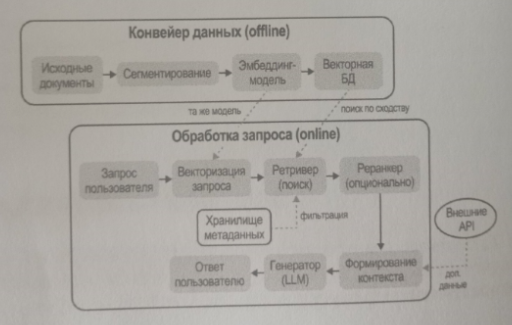

## 2.1. Основные компоненты RAG‑систем

### Общая логика архитектуры

Схема отражает два основных потока:  
* **офлайн‑подготовку данных** — формирует основу знаний системы; качество этого этапа задаёт верхний предел эффективности RAG;  
* **онлайн‑обработку запросов** — отвечает за скорость ответа и пользовательский опыт.

### Конвейер данных: офлайн‑подготовка

Этот этап создаёт базу знаний для RAG‑системы и включает последовательные шаги:

1. **Загрузка и нормализация исходных документов** из разнородных источников: текстовых файлов, PDF, веб‑страниц, записей из баз данных. Для работы с разными форматами требуются универсальные загрузчики, способные извлекать чистый текст.  
2. **Сегментирование (чанкирование)** — разбиение документов на логически связанные фрагменты оптимального размера (обычно 100–1000 токенов). Критически важно соблюсти баланс: слишком маленькие чанки теряют контекст, слишком большие могут содержать разнородную информацию, снижающую точность поиска.  
3. **Преобразование в эмбеддинги** с помощью эмбеддинг‑модели: текстовые фрагменты кодируются в числовые векторы, отражающие их семантическое содержание. Выбор модели критичен — она должна эффективно работать с предметной областью и языком документов.  
4. **Хранение в векторной базе данных**, оптимизированной для быстрого поиска высокомерных векторов. Среди современных решений упоминаются Pinecone, Weaviate, Qdrant, Chroma — они предлагают разные компромиссы между скоростью, точностью и функциональностью.

### Обработка запросов: онлайн‑поток

При поступлении пользовательского запроса система выполняет следующие действия:

* **Векторизация запроса** с использованием той же эмбеддинг‑модели, что применялась при индексации документов. Это обеспечивает совместимость векторных представлений и корректность поиска по сходству.  
* **Работа ретривера (retriever)** — семантический поиск в векторном пространстве для нахождения K наиболее похожих фрагментов. Современные ретриверы поддерживают гибридный поиск, комбинируя векторное сходство с лексическими методами (например, BM25) для повышения точности.  
* **Опциональная работа реранкера (reranker)** — специализированные модели анализируют найденные фрагменты в контексте конкретного запроса и переранжируют их, более точно оценивая релевантность. Это особенно эффективно при работе со сложными или многоаспектными запросами.

### Дополнительные компоненты

В архитектуре также задействованы:  
* хранилище метаданных (с функцией фильтрации);  
* внешние API (для получения дополнительных данных);  
* генератор на базе LLM — формирует итоговый ответ пользователю на основе собранного контекста.

### Формирование контекста и генерация

На этом этапе система превращает найденные фрагменты в осмысленный ответ:

* **Модуль аугментации (augmentation)** объединяет релевантные фрагменты с исходным запросом пользователя, формируя расширенный промпт для языковой модели. В рамках аугментации часто выполняют дополнительную обработку: сжатие контекста (чтобы уложиться в лимиты токенов), удаление дубликатов и структурирование информации (например, в виде списка или JSON).  
* **Генератор (LLM)** получает обогащённый контекст и формирует финальный ответ. Ключевое преимущество такого подхода — модель опирается не только на свои параметрические знания (заложенные при обучении), но и на предоставленную актуальную информацию. Это существенно снижает количество галлюцинаций и повышает достоверность ответа.

### Дополнительные компоненты

Эти модули расширяют функциональность и встраивают RAG в корпоративную среду:

* **Хранилище метаданных** дополняет поиск атрибутами документов: дата создания, автор, категория, права доступа. Это позволяет фильтровать результаты и обеспечивать релевантность на уровне бизнес‑логики (например, показывать только документы с уровнем допуска «для сотрудников отдела»).  
* **Внешние API** интегрируют RAG с корпоративными системами (CRM, ERP) и внешними сервисами, превращая его в универсальный интерфейс к экосистеме данных.  
* **Подсистема мониторинга и журналирования** отслеживает качество работы каждого компонента. В неё входят метрики производительности, анализ пользовательской активности и A/B‑тестирование разных конфигураций. Хотя эта подсистема не показана на архитектурных диаграммах (она как бы охватывает все компоненты), она критически важна для непрерывного улучшения системы.

### Модульность и масштабируемость

Это ключевое преимущество RAG‑архитектуры:

* **Независимое масштабирование.** Каждый компонент можно оптимизировать отдельно: эмбеддинг‑модель — заменить на более эффективную, векторную БД — масштабировать горизонтально, ретривер — настроить под специфику предметной области.  
* **Итеративное развитие.** Архитектура позволяет начать с простой реализации и постепенно наращивать сложность: добавлять реранкинг, гибридный поиск, поддержку мультимодальных данных или агентские возможности. Такой подход делает RAG идеальной технологией для развивающихся продуктов.  

Понимание роли каждого компонента и принципов их взаимодействия — основа для проектирования эффективных RAG‑систем. В следующих разделах книги рассматриваются архитектурные паттерны и методы интеграции этих компонентов в единую высокопроизводительную систему.

## 2.2. Архитектурные паттерны: от классики к автономным системам

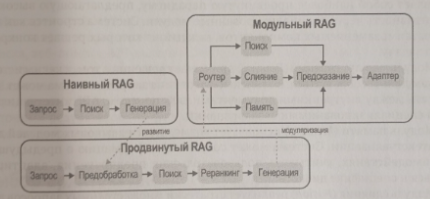

За несколько лет появилось несколько разных архитектур RAG. Каждая решает свои задачи и выбирает свой баланс между простотой, эффективностью и возможностями.

**Эволюция архитектур**

Развитие шло от понимания слабых мест простых систем к созданию более сложных и гибких. Каждый новый тип наследует удачные решения предыдущего и добавляет что-то своё.

**Наивный RAG**

Это самая простая схема: документы режутся на куски, переводятся в векторы и сохраняются. По запросу система находит похожие куски и отдаёт их языковой модели вместе с вопросом.

*Плюсы:* легко сделать, предсказуемо работает, просто отлаживать. Для простых задач (FAQ-боты, техподдержка) этого достаточно.

*Минусы:* не справляется со сложными вопросами, где нужно собрать информацию из разных мест. Нет контроля над качеством поиска — в ответ может попасть мусор.

**Продвинутый RAG**

Добавляет обработку запроса до и после поиска, чтобы улучшить результат.

*Что делает до поиска:*
- Расширяет запрос синонимами, разбивает на части или переформулирует, чтобы лучше совпадало с документами.
- Улучшает индексацию: режет текст с перекрытием, сохраняет иерархию кусков, добавляет метаданные. Так контекст не теряется и поиск становится точнее.

*Что делает после поиска:*
- **Реранкинг** — специальная модель перепроверяет найденные куски и перестраивает их по настоящей полезности для конкретного запроса (кросс-энкодеры сильно поднимают качество).
- **Гибридный поиск** — смешивает векторный и текстовый поиск (например, BM25) и объединяет результаты через Reciprocal Rank Fusion (RRF), беря лучшее от обоих методов.

---
**BM25** — это формула ранжирования, которая оценивает релевантность документа запросу по «мешку слов». Принцип: чем чаще редкие слова запроса встречаются в документе, тем выше вес, но с насыщением (много повторов не дают бесконечного роста), с поправкой на длину документа.

**Reciprocal Rank Fusion (RRF)** — это метод слияния нескольких ранжированных списков в один. Принцип: итоговый score элемента = сумма обратных величин его позиций в каждом из списков (`1 / (k + rank)`). Позиции в топе дают основной вклад, а аутсайдеры почти не влияют.

---

**Модульный RAG**

Самая гибкая система, собранная из сменных блоков под разные задачи.

- **Маршрутизация (Routing)** — решает, куда идти за ответом: внутренние документы, интернет, API или специальная база знаний.
- **Память (Memory)** — запоминает историю общения, учитывает предпочтения пользователя и адаптируется по ходу диалога.
- **Слияние (Fusion)** — превращает один запрос в несколько разных формулировок, ищет по каждой, а затем объединяет и фильтрует результаты для большей полноты.
- **Предсказание** — модель сама достраивает контекст запроса, «додумывая» недостающее, чтобы искать по более полной картине.

**Агентный RAG**

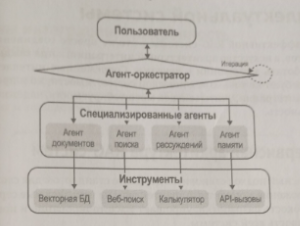

Это следующий шаг — системы, которые сами планируют, адаптируются и улучшают результат по ходу дела, а не идут по жёсткому сценарию.

*Как устроено (по схеме):*
- Пользователь общается с **агентом-оркестратором**, который может делать итерации.
- Оркестратор управляет **специализированными агентами**: по документам, поиску, рассуждениям, памяти.
- Те, в свою очередь, используют **инструменты**: векторную базу, веб-поиск, калькулятор, вызовы API.

*Моноагентный RAG* — частный случай, где один агент-оркестратор на лету решает, какой инструмент применить под конкретный запрос. Никакого заранее прописанного маршрута.

**Сильные стороны агентных систем:**
- **Автономность** — сами решают, что делать.
- **Адаптивность** — меняют стратегию по промежуточным результатам.
- **Проактивность** — предугадывают потребности пользователя и справляются с многоэтапными задачами.

**Как выбирать архитектуру:**

- **Наивный RAG** — простые задачи, маленький бюджет.
- **Продвинутый RAG** — когда важно высокое качество ответов.
- **Модульный RAG** — сложные корпоративные системы с кучей разных источников данных.
- **Агентные архитектуры** — сложная аналитика, много источников, меняющиеся условия. Разработка и поддержка ощутимо дороже.

**Общий вектор развития:** RAG-архитектуры становятся всё более автономными, специализированными и гибкими, чтобы точнее закрывать бизнес-задачи.